# Stuff+ Model: Training and Analysis

This notebook trains an XGBoost model to predict pitch quality (Stuff+) based on pitch characteristics.

## Setup and Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r "/content/drive/MyDrive/stuff_model/data/" "/content/"

In [3]:
!mkdir /content/model_storage/

In [4]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import joblib

# Analysis libraries
import shap
from scipy.stats import zscore
from scipy import stats
from tqdm.notebook import tqdm

In [5]:
%matplotlib inline

In [6]:
# Model configuration
features = ['release_speed',
            'release_spin_rate',
            'spin_axis',
            'release_extension',
            'az',
            'ax',
            'release_pos_x',
            'release_pos_z',
            'speed_diff',
            'az_diff',
            'ax_diff',
            'stand',
            'p_throws']

target = 'target'
seed = 1126

## Helper Functions

In [7]:
def evaluate_cv_results(cv_scores):
    """Print cross-validation results"""
    print(f'Cross-Validation RMSE scores: {cv_scores}')
    print(f'Mean CV RMSE: {np.mean(cv_scores):.6f}')
    print(f'Std CV RMSE: {np.std(cv_scores):.6f}')
    return np.mean(cv_scores)

In [26]:
def calculate_stuff_plus(df, ref_mean=None, ref_std=None):
    """
    Calculate Stuff+ on 20-80 scouting scale across all pitch types.

    Args:
        df: DataFrame containing 'y_pred'
        ref_mean: Optional reference mean from training data (for inference stability)
        ref_std: Optional reference std from training data
    """
    preds = df['y_pred'].values

    if ref_mean is not None and ref_std is not None:
        # Use fixed scaling statistics (safe for inference/subsets)
        z_scores = (preds - ref_mean) / ref_std
    else:
        # Use batch statistics (analysis mode)
        # Z-score across ALL pitches in the current dataframe
        z_scores = zscore(preds)

    # Scale to 20-80: 50 is average, each 10 points = 1 std dev
    stuff_plus = 50 - z_scores * 10

    # Force results within 20-80 range
    stuff_plus = np.clip(stuff_plus, 20, 80)

    df['stuff_plus'] = stuff_plus
    return df

## Prepare Data

In [9]:
# Load data
all_data = pl.read_csv('./data/train_data.csv')

In [10]:
# Convert categorical columns
all_data = all_data.with_columns([
    pl.col("p_throws").cast(pl.Categorical),
    pl.col("stand").cast(pl.Categorical)
])

In [11]:
# Drop nulls and convert to pandas
all_data = all_data.drop_nulls(subset = features + [target])
all_data = all_data.to_pandas()

# Ensure categorical columns are properly typed for XGBoost/LightGBM
# Both libraries prefer 'category' dtype over object/string for performance and correctness
categorical_cols = ['p_throws', 'stand']
for col in categorical_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].astype('category')

In [12]:
# Preview data
all_data.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,des_new,count,swing,target,avg_fastball_speed,avg_fastball_az,avg_fastball_ax,speed_diff,az_diff,ax_diff
0,FF,2021-10-03,92.3,-1.40,6.80,"Smith, Will",596019,519293,field_out,hit_into_play,...,field_out,1-2,True,-0.171930,92.782745,-13.010536,8.233451,-0.482745,-1.072688,-17.941844
1,SL,2021-10-03,80.6,-1.60,6.64,"Smith, Will",596019,519293,None,foul,...,foul,1-1,True,-0.063750,92.782745,-13.010536,8.233451,-12.182745,-14.358578,-1.702328
2,CU,2021-10-03,75.5,-1.46,6.88,"Smith, Will",596019,519293,None,foul,...,foul,1-0,True,-0.049593,92.782745,-13.010536,8.233451,-17.282745,-23.251648,-3.360527
3,CU,2021-10-03,75.0,-1.53,6.83,"Smith, Will",596019,519293,None,ball,...,ball,0-0,False,0.036807,92.782745,-13.010536,8.233451,-17.782745,-25.274212,-2.330795
4,FF,2021-10-03,91.2,-1.49,6.66,"Smith, Will",607043,519293,field_out,hit_into_play,...,field_out,1-0,True,-0.289289,92.782745,-13.010536,8.233451,-1.582745,-2.930638,-16.934037


In [13]:
# Prepare features and target
all_x = all_data[features]
all_y = all_data[target]

print(f"Total samples: {all_x.shape[0]:,}")
print(f"Features: {all_x.shape[1]}")

Total samples: 2,820,061
Features: 13


## Model Training

### Setup Cross-Validation

In [ ]:
# Setup 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=seed)
print(f"Using 5-fold cross-validation with {all_x.shape[0]:,} total samples")

Using 5-fold cross-validation with 2,820,061 total samples


### XGBoost Model

In [ ]:
# XGBoost parameters
xgb_params = {
    'objective': 'reg:squarederror',
    'max_depth': 20,
    'learning_rate': 0.05,
    'eval_metric': 'rmse',
    'random_state': seed,
    'tree_method': 'hist',
    'n_jobs': -1,
    'device': 'cuda'
}
xgb_num_rounds = 500

In [ ]:
# XGBoost: 5-Fold Cross-Validation
print("=" * 60)
print("XGBoost Cross-Validation")
print("=" * 60)

xgb_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_x), 1):
    print(f"\nFold {fold}/5")

    # Split data
    x_train_fold, x_val_fold = all_x.iloc[train_idx], all_x.iloc[val_idx]
    y_train_fold, y_val_fold = all_y.iloc[train_idx], all_y.iloc[val_idx]

    # Create DMatrix
    d_train = xgb.DMatrix(x_train_fold, label=y_train_fold, enable_categorical=True)
    d_val = xgb.DMatrix(x_val_fold, label=y_val_fold, enable_categorical=True)

    # Train model
    model = xgb.train(xgb_params, d_train, xgb_num_rounds)

    # Evaluate
    val_pred = model.predict(d_val)
    fold_rmse = root_mean_squared_error(y_val_fold, val_pred)
    xgb_cv_scores.append(fold_rmse)

    print(f"Fold {fold} Validation RMSE: {fold_rmse:.6f}")

print("\n" + "=" * 60)
print("XGBoost Cross-Validation Results")
print("=" * 60)
xgb_mean_cv_score = evaluate_cv_results(xgb_cv_scores)

XGBoost Cross-Validation

Fold 1/5
Fold 1 Validation RMSE: 0.220419

Fold 2/5
Fold 2 Validation RMSE: 0.219636

Fold 3/5
Fold 3 Validation RMSE: 0.220782

Fold 4/5
Fold 4 Validation RMSE: 0.220037

Fold 5/5
Fold 5 Validation RMSE: 0.220106

XGBoost Cross-Validation Results
Cross-Validation RMSE scores: [0.22041926745822576, 0.2196357667955598, 0.22078218378148812, 0.22003741800236623, 0.2201063110697149]
Mean CV RMSE: 0.220196
Std CV RMSE: 0.000385


In [ ]:
# Train final XGBoost model on ALL data
print("\n" + "=" * 60)
print("Training Final XGBoost Model on ALL Data")
print("=" * 60)

d_all = xgb.DMatrix(all_x, label=all_y, enable_categorical=True)
xgb_model = xgb.train(xgb_params, d_all, xgb_num_rounds)

print(f"Final XGBoost model trained on {all_x.shape[0]:,} samples")
print(f"Expected generalization RMSE (from CV): {xgb_mean_cv_score:.6f}")


Training Final XGBoost Model on ALL Data
Final XGBoost model trained on 2,820,061 samples
Expected generalization RMSE (from CV): 0.220196


In [ ]:
# Save XGBoost model
filename = './model_storage/xgboost_model.joblib'
joblib.dump(xgb_model, filename)
print(f"Model saved to {filename}")

Model saved to ./model_storage/xgboost_model.joblib


In [ ]:
!cp "/content/model_storage/xgboost_model.joblib"  "/content/drive/MyDrive/stuff_model/model_storage/"

### LightGBM Model

In [ ]:
# LightGBM parameters
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'device_type': 'cpu',
    'num_threads': -1,
    'learning_rate': 0.02,
    'random_state': seed
}
lgb_num_rounds = 1000

In [ ]:
# LightGBM: 5-Fold Cross-Validation
print("=" * 60)
print("LightGBM Cross-Validation")
print("=" * 60)

lgb_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_x), 1):
    print(f"\nFold {fold}/5")

    # Split data
    x_train_fold, x_val_fold = all_x.iloc[train_idx], all_x.iloc[val_idx]
    y_train_fold, y_val_fold = all_y.iloc[train_idx], all_y.iloc[val_idx]

    # Create Dataset
    # Explicitly define categorical features and use training set as reference for validation
    d_train = lgb.Dataset(x_train_fold, label=y_train_fold, categorical_feature=categorical_cols)
    d_val = lgb.Dataset(x_val_fold, label=y_val_fold, reference=d_train)

    # Train model
    model = lgb.train(lgb_params, d_train, lgb_num_rounds)

    # Evaluate
    val_pred = model.predict(x_val_fold)
    fold_rmse = root_mean_squared_error(y_val_fold, val_pred)
    lgb_cv_scores.append(fold_rmse)

    print(f"Fold {fold} Validation RMSE: {fold_rmse:.6f}")

print("\n" + "=" * 60)
print("LightGBM Cross-Validation Results")
print("=" * 60)
lgb_mean_cv_score = evaluate_cv_results(lgb_cv_scores)

LightGBM Cross-Validation

Fold 1/5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2610
[LightGBM] [Info] Number of data points in the train set: 2256048, number of used features: 13
[LightGBM] [Info] Start training from score 0.000016
Fold 1 Validation RMSE: 0.215928

Fold 2/5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2611
[LightGBM] [Info] Number of data points in the train set: 2256049, number of used features: 13
[LightGBM] [Info] Start training from score 0.000047
Fold 2 Validation RMSE: 0.214970

Fold 3/5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the 

In [ ]:
# Train final LightGBM model on ALL data
print("\n" + "=" * 60)
print("Training Final LightGBM Model on ALL Data")
print("=" * 60)

d_all = lgb.Dataset(all_x, label=all_y, categorical_feature=categorical_cols)
lgb_model = lgb.train(lgb_params, d_all, lgb_num_rounds)

print(f"Final LightGBM model trained on {all_x.shape[0]:,} samples")
print(f"Expected generalization RMSE (from CV): {lgb_mean_cv_score:.6f}")


Training Final LightGBM Model on ALL Data
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055731 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2609
[LightGBM] [Info] Number of data points in the train set: 2820061, number of used features: 13
[LightGBM] [Info] Start training from score 0.000012
Final LightGBM model trained on 2,820,061 samples
Expected generalization RMSE (from CV): 0.215627


In [ ]:
# Save LightGBM model
filename = './model_storage/lightgbm_model.joblib'
joblib.dump(lgb_model, filename)
print(f"Model saved to {filename}")

Model saved to ./model_storage/lightgbm_model.joblib


In [ ]:
!cp "/content/model_storage/lightgbm_model.joblib"  "/content/drive/MyDrive/stuff_model/model_storage/"

## Model Analysis

This section analyzes the trained Stuff+ model through:
1. **Feature Analysis**: Understanding feature importance and interactions
2. **Temporal Validation**: Year-over-year consistency across multiple seasons
3. **Stability Analysis**: Sample size requirements for reliable estimates
4. **Prediction Distribution Analysis**: Distribution of Stuff+ ratings

**Note**: We use the LightGBM model for analysis as it showed better performance (RMSE: 0.2156 vs 0.2202 for XGBoost).

### Generate Predictions

In [14]:
!cp -r "/content/drive/MyDrive/stuff_model/model_storage/" "/content/"

In [ ]:
# Load the trained LightGBM model and generate predictions
filename = './model_storage/lightgbm_model.joblib'
lgb_model = joblib.load(filename)

In [27]:
# Generate predictions for all data
all_data.loc[:, 'y_pred'] = lgb_model.predict(all_data.loc[:, features])

# Calculate training set statistics for scaling
# (In a real pipeline, these should be saved with the model to apply to new data)
ref_mean = all_data['y_pred'].mean()
ref_std = all_data['y_pred'].std()

print(f"Stuff+ Scaling Reference: Mean={ref_mean:.4f}, Std={ref_std:.4f}")

# Calculate Stuff+ on 20-80 scale using fixed reference
all_data = calculate_stuff_plus(all_data, ref_mean=ref_mean, ref_std=ref_std)

print(f"Predictions generated for {len(all_data):,} pitches")
print(f"Stuff+ range: {all_data['stuff_plus'].min():.1f} to {all_data['stuff_plus'].max():.1f}")

Stuff+ Scaling Reference: Mean=0.0000, Std=0.0075
Predictions generated for 2,820,061 pitches
Stuff+ range: 20.0 to 80.0


In [28]:
all_data['stuff_plus']

,stuff_plus
0,30.945819
1,58.424249
2,37.439719
3,44.191982
4,29.218666
...,...
2820056,39.146103
2820057,56.811571
2820058,45.848249
2820059,58.564199


## 1. Feature Analysis

Understanding which features drive Stuff+ predictions and how they interact.

### 1.1 LightGBM Built-in Feature Importance

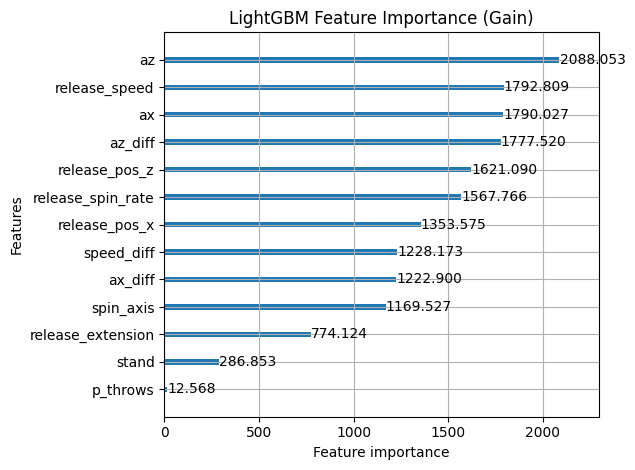

In [20]:
lgb.plot_importance(lgb_model, max_num_features=13, importance_type='gain')
plt.title('LightGBM Feature Importance (Gain)')
plt.tight_layout()
plt.show()

### 1.2 SHAP Analysis for Feature Interactions

In [22]:
# Sample data for SHAP (using full data is too slow)
sample_size = 10000
sample_data = all_data.sample(n=sample_size, random_state=seed)
X_sample = sample_data[features]

print(f"Computing SHAP values for {sample_size:,} pitches...")
print("This may take a few minutes...")

# Create SHAP explainer for LightGBM
explainer = shap.TreeExplainer(lgb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

Computing SHAP values for 10,000 pitches...
This may take a few minutes...



SHAP FEATURE IMPORTANCE


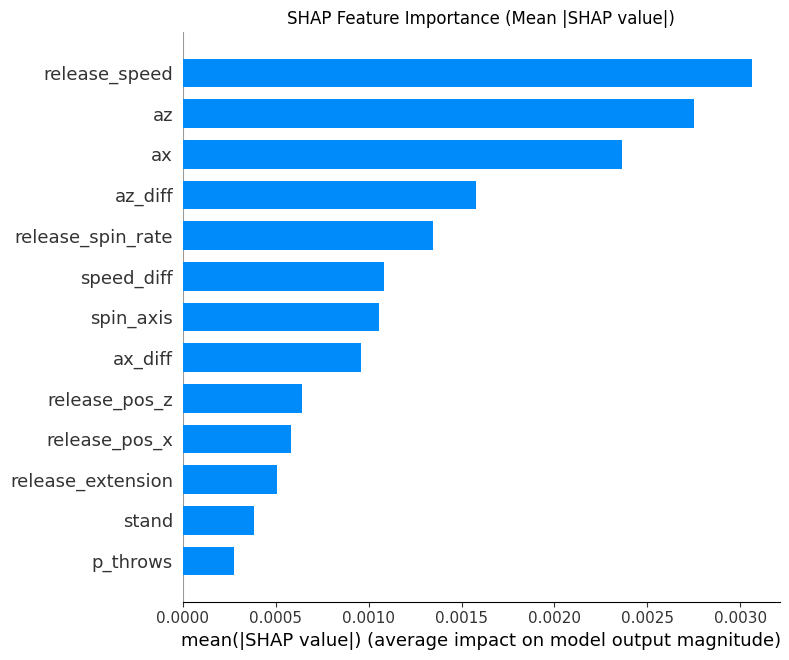

In [23]:
# SHAP Summary Plot: Overall feature importance
print("\n" + "=" * 60)
print("SHAP FEATURE IMPORTANCE")
print("=" * 60)

shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP value|)")
plt.tight_layout()
plt.show()


SHAP FEATURE EFFECTS
Red = high feature value, Blue = low feature value
Right = increases prediction, Left = decreases prediction


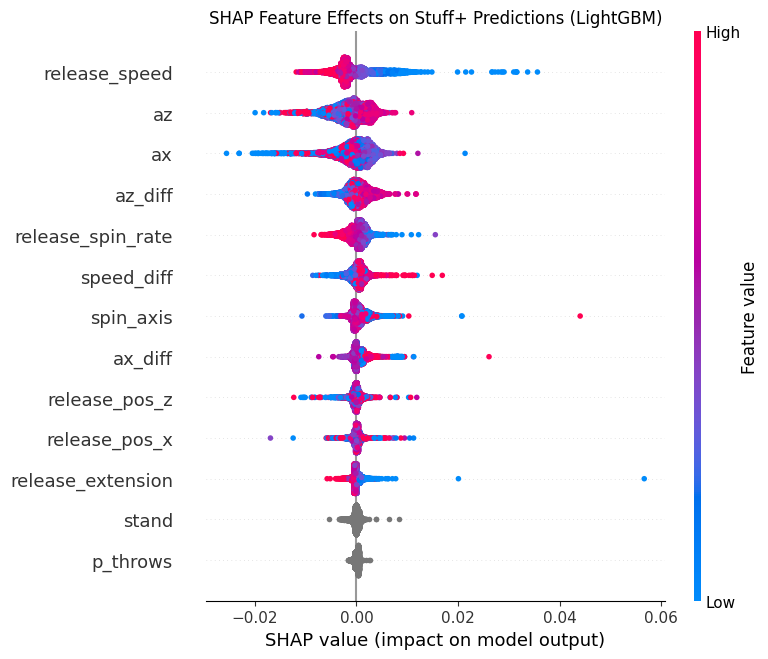

In [24]:
# SHAP Beeswarm Plot: Feature effects and interactions
print("\n" + "=" * 60)
print("SHAP FEATURE EFFECTS")
print("=" * 60)
print("Red = high feature value, Blue = low feature value")
print("Right = increases prediction, Left = decreases prediction")

shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Feature Effects on Stuff+ Predictions (LightGBM)")
plt.tight_layout()
plt.show()


SHAP DEPENDENCE PLOTS (Feature Interactions)
Top 3 features: ['release_speed', 'az', 'ax']


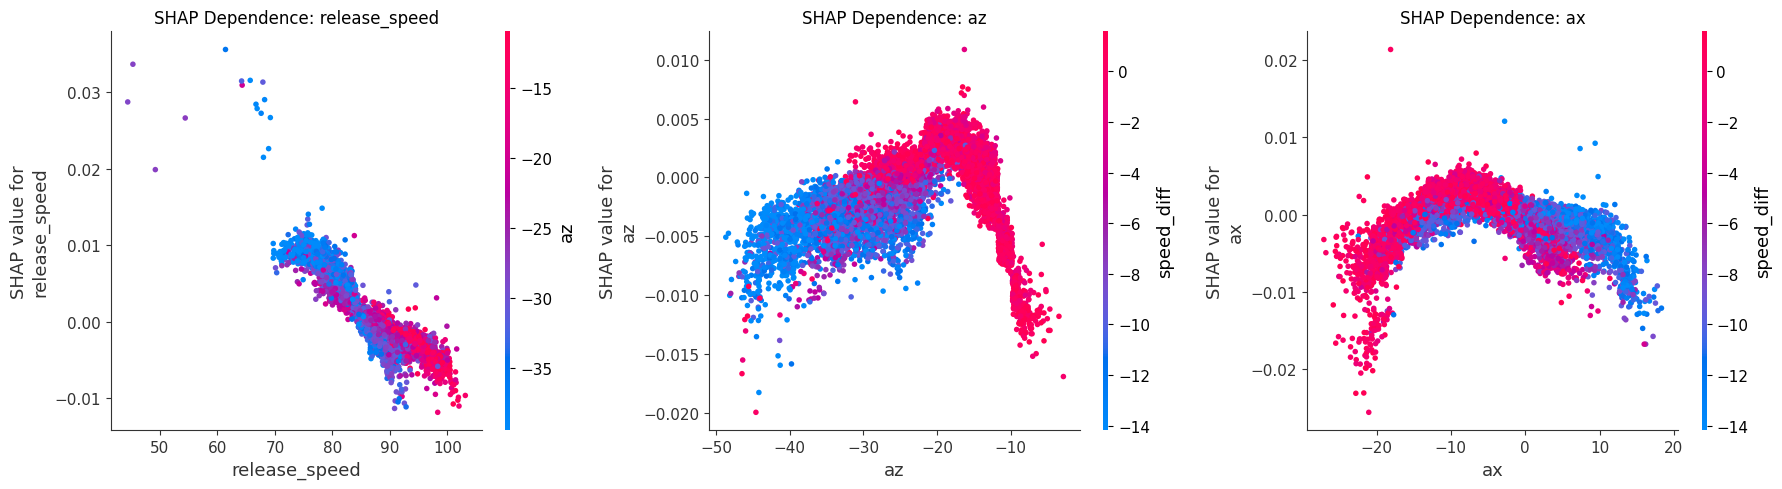


Interpretation:
- X-axis: Feature value
- Y-axis: SHAP value (impact on prediction)
- Color: Interaction with another feature (auto-selected)


In [29]:
# SHAP Dependence Plots: Top 3 features
print("\n" + "=" * 60)
print("SHAP DEPENDENCE PLOTS (Feature Interactions)")
print("=" * 60)

# Get top 3 most important features
feature_importance = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(feature_importance)[-3:][::-1]
top_features = [features[i] for i in top_features_idx]

print(f"Top 3 features: {top_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (feat_idx, feat_name) in enumerate(zip(top_features_idx, top_features)):
    plt.sca(axes[i])
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_sample,
        show=False,
        ax=axes[i]
    )
    axes[i].set_title(f"SHAP Dependence: {feat_name}")

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- X-axis: Feature value")
print("- Y-axis: SHAP value (impact on prediction)")
print("- Color: Interaction with another feature (auto-selected)")

## 2. Temporal Validation

Analyzing year-over-year stability of Stuff+ ratings across multiple seasons.

### 2.1 Split Data by Year

In [30]:
# Split data by year for temporal analysis
data_2021 = all_data.loc[(all_data['game_date'] >= '2021-01-01') & (all_data['game_date'] < '2022-01-01'), :]
data_2022 = all_data.loc[(all_data['game_date'] >= '2022-01-01') & (all_data['game_date'] < '2023-01-01'), :]
data_2023 = all_data.loc[(all_data['game_date'] >= '2023-01-01') & (all_data['game_date'] < '2024-01-01'), :]
data_2024 = all_data.loc[(all_data['game_date'] >= '2024-01-01') & (all_data['game_date'] < '2025-01-01'), :]

print("=" * 60)
print("TEMPORAL DATA SPLIT")
print("=" * 60)
print(f"2021 pitches: {len(data_2021):,}")
print(f"2022 pitches: {len(data_2022):,}")
print(f"2023 pitches: {len(data_2023):,}")
print(f"2024 pitches: {len(data_2024):,}")

TEMPORAL DATA SPLIT
2021 pitches: 703,201
2022 pitches: 703,727
2023 pitches: 710,396
2024 pitches: 702,737


### 2.2 Calculate Year-over-Year Correlations

In [31]:
def calculate_yoy_stability(year1_data, year2_data, year1_name, year2_name, min_pitches=200):
    """Calculate year-over-year stability for Stuff+."""
    # Group by pitcher and pitch type
    year1_grouped = year1_data.groupby(['pitcher', 'pitch_type']).agg(
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    )

    year2_grouped = year2_data.groupby(['pitcher', 'pitch_type']).agg(
        avg_stuff_plus=('stuff_plus', 'mean'),
        pitches=('stuff_plus', 'count')
    )

    # Filter by minimum pitches
    year1_grouped = year1_grouped[year1_grouped['pitches'] >= min_pitches]
    year2_grouped = year2_grouped[year2_grouped['pitches'] >= min_pitches]

    # Merge on both pitcher and pitch_type
    merged = pd.merge(
        year1_grouped,
        year2_grouped,
        left_index=True,
        right_index=True,
        suffixes=(f'_{year1_name}', f'_{year2_name}')
    )

    # Calculate correlation
    if len(merged) > 0:
        corr = np.corrcoef(
            merged[f'avg_stuff_plus_{year1_name}'],
            merged[f'avg_stuff_plus_{year2_name}']
        )[0, 1]
        r2 = corr ** 2
    else:
        corr = np.nan
        r2 = np.nan

    return merged, corr, r2

In [32]:
# Calculate stability for all year pairs
min_pitches = 200
year_pairs = [
    (data_2021, data_2022, '2021', '2022'),
    (data_2022, data_2023, '2022', '2023'),
    (data_2023, data_2024, '2023', '2024')
]

print("\n" + "=" * 60)
print("YEAR-OVER-YEAR STABILITY ANALYSIS")
print("=" * 60)

stability_results = []

for year1_data, year2_data, year1_name, year2_name in year_pairs:
    merged, corr, r2 = calculate_yoy_stability(
        year1_data, year2_data, year1_name, year2_name, min_pitches
    )

    stability_results.append({
        'comparison': f'{year1_name}→{year2_name}',
        'correlation': corr,
        'r_squared': r2,
        'n_pitchers': len(merged)
    })

    print(f"\n{year1_name} → {year2_name}:")
    print(f"  Correlation: {corr:.4f}")
    print(f"  R²: {r2:.4f}")
    print(f"  N (pitcher-pitch combinations): {len(merged)}")

stability_df = pd.DataFrame(stability_results)
print("\n" + "=" * 60)
print("TEMPORAL STABILITY SUMMARY")
print("=" * 60)
print(stability_df.to_string(index=False))


YEAR-OVER-YEAR STABILITY ANALYSIS

2021 → 2022:
  Correlation: 0.8923
  R²: 0.7962
  N (pitcher-pitch combinations): 719

2022 → 2023:
  Correlation: 0.8910
  R²: 0.7938
  N (pitcher-pitch combinations): 722

2023 → 2024:
  Correlation: 0.8757
  R²: 0.7668
  N (pitcher-pitch combinations): 722

TEMPORAL STABILITY SUMMARY
comparison  correlation  r_squared  n_pitchers
 2021→2022     0.892279   0.796162         719
 2022→2023     0.890952   0.793795         722
 2023→2024     0.875689   0.766832         722


### 2.3 Visualize Year-over-Year Stability

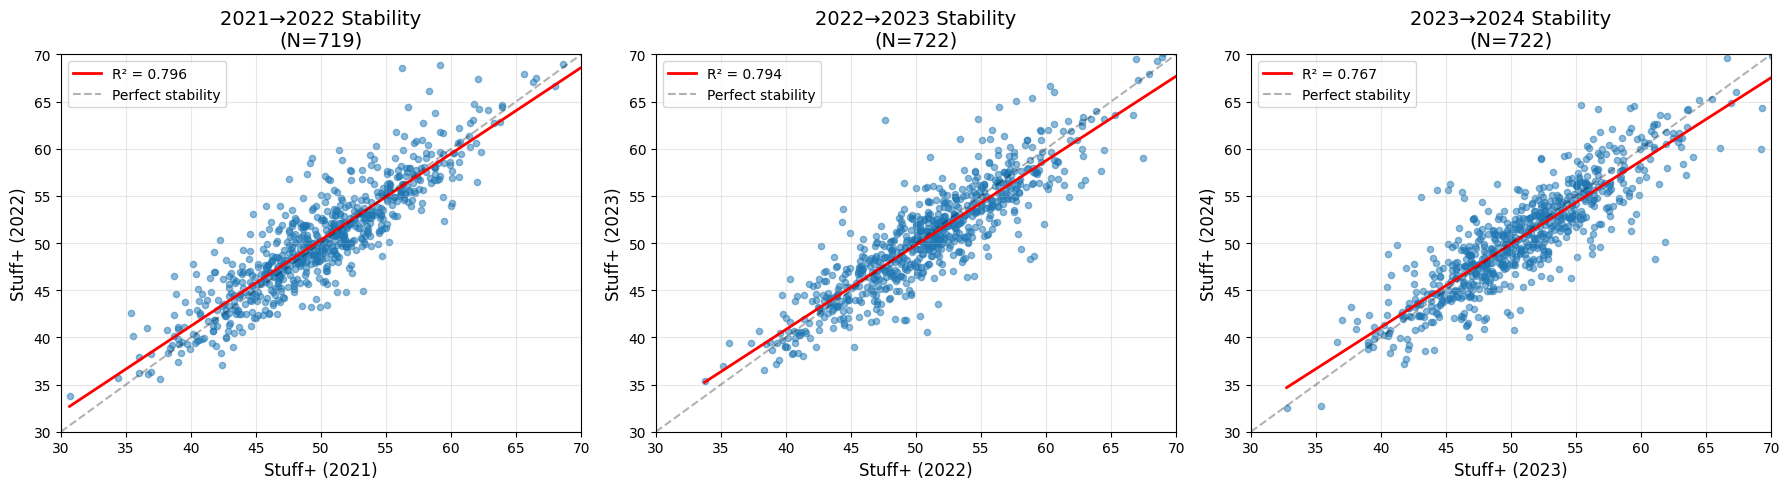

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (year1_data, year2_data, year1_name, year2_name) in enumerate(year_pairs):
    merged, corr, r2 = calculate_yoy_stability(
        year1_data, year2_data, year1_name, year2_name, min_pitches
    )

    ax = axes[idx]
    ax.scatter(
        merged[f'avg_stuff_plus_{year1_name}'],
        merged[f'avg_stuff_plus_{year2_name}'],
        alpha=0.5,
        s=20
    )

    # Add regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged[f'avg_stuff_plus_{year1_name}'],
        merged[f'avg_stuff_plus_{year2_name}']
    )
    x_line = np.array([merged[f'avg_stuff_plus_{year1_name}'].min(),
                       merged[f'avg_stuff_plus_{year1_name}'].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'R² = {r2:.3f}')

    # Add 1:1 reference line
    ax.plot([30, 70], [30, 70], 'k--', alpha=0.3, label='Perfect stability')

    ax.set_xlabel(f'Stuff+ ({year1_name})', fontsize=12)
    ax.set_ylabel(f'Stuff+ ({year2_name})', fontsize=12)
    ax.set_title(f'{year1_name}→{year2_name} Stability\n(N={len(merged)})', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(30, 70)
    ax.set_ylim(30, 70)

plt.tight_layout()
plt.show()

### 2.4 Stability by Pitch Type


STABILITY BY PITCH TYPE (All Year Transitions)
FF: Average R² = 0.749 (across 3 year transitions)
SL: Average R² = 0.783 (across 3 year transitions)
CH: Average R² = 0.761 (across 3 year transitions)
CU: Average R² = 0.788 (across 3 year transitions)
SI: Average R² = 0.796 (across 3 year transitions)
FC: Average R² = 0.818 (across 3 year transitions)


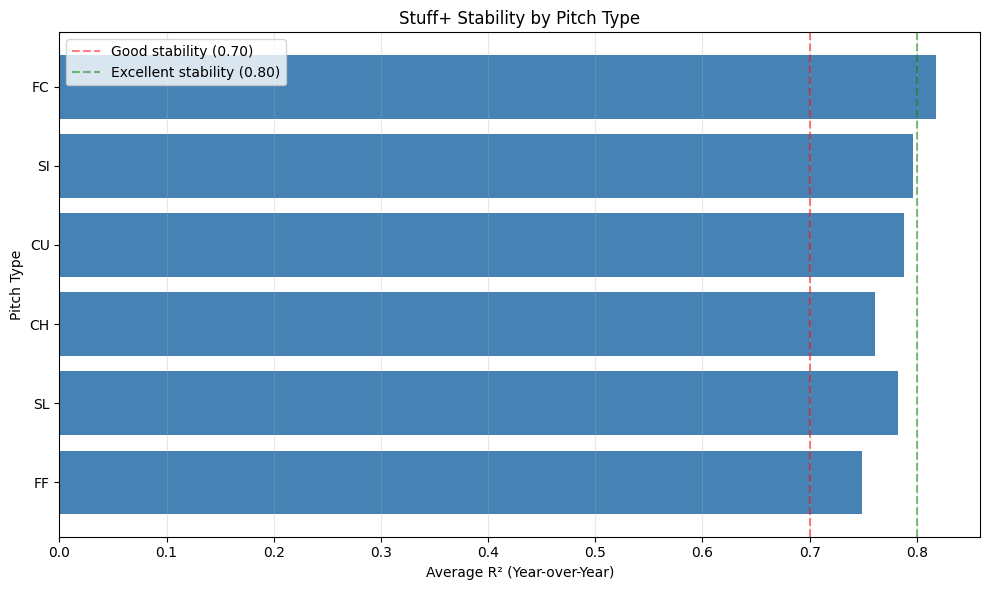

In [35]:
print("\n" + "=" * 60)
print("STABILITY BY PITCH TYPE (All Year Transitions)")
print("=" * 60)

pitch_types_to_analyze = ['FF', 'SL', 'CH', 'CU', 'SI', 'FC']

stability_by_pitch_type = []

for pitch_type in pitch_types_to_analyze:
    pitch_correlations = []

    for year1_data, year2_data, year1_name, year2_name in year_pairs:
        # Filter by pitch type
        y1_filtered = year1_data[year1_data['pitch_type'] == pitch_type]
        y2_filtered = year2_data[year2_data['pitch_type'] == pitch_type]

        if len(y1_filtered) > 0 and len(y2_filtered) > 0:
            # Group by pitcher only (since we already filtered pitch type)
            y1_grouped = y1_filtered.groupby('pitcher').agg(
                avg_stuff_plus=('stuff_plus', 'mean'),
                pitches=('stuff_plus', 'count')
            )

            y2_grouped = y2_filtered.groupby('pitcher').agg(
                avg_stuff_plus=('stuff_plus', 'mean'),
                pitches=('stuff_plus', 'count')
            )

            # Filter by minimum pitches
            y1_grouped = y1_grouped[y1_grouped['pitches'] >= min_pitches]
            y2_grouped = y2_grouped[y2_grouped['pitches'] >= min_pitches]

            # Merge on pitcher
            merged = pd.merge(y1_grouped, y2_grouped, left_index=True, right_index=True,
                            suffixes=('_y1', '_y2'))

            if len(merged) >= 10:  # Need minimum sample
                corr = np.corrcoef(merged['avg_stuff_plus_y1'], merged['avg_stuff_plus_y2'])[0, 1]
                r2 = corr ** 2
                pitch_correlations.append(r2)

    if len(pitch_correlations) > 0:
        avg_r2 = np.mean(pitch_correlations)
        stability_by_pitch_type.append({
            'pitch_type': pitch_type,
            'avg_r2': avg_r2,
            'n_years': len(pitch_correlations)
        })
        print(f"{pitch_type}: Average R² = {avg_r2:.3f} (across {len(pitch_correlations)} year transitions)")

# Visualize
if len(stability_by_pitch_type) > 0:
    stability_pt_df = pd.DataFrame(stability_by_pitch_type)

    plt.figure(figsize=(10, 6))
    plt.barh(stability_pt_df['pitch_type'], stability_pt_df['avg_r2'], color='steelblue')
    plt.axvline(x=0.7, color='red', linestyle='--', alpha=0.5, label='Good stability (0.70)')
    plt.axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='Excellent stability (0.80)')
    plt.xlabel('Average R² (Year-over-Year)')
    plt.ylabel('Pitch Type')
    plt.title('Stuff+ Stability by Pitch Type')
    plt.legend()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 3. Stability Analysis

Using split-half reliability to determine minimum sample sizes needed for stable Stuff+ ratings.

### 3.1 Split-Half Reliability Function

In [53]:
def perform_split_half_analysis(groups, sample_size, n_iterations=10):
    """
    Calculates reliability for a given sample size across a set of pitcher-pitch groups.

    Args:
        groups: List of DataFrames, where each DF is a pitcher-pitch_type combination.
        sample_size: Number of pitches to sample from each group.
        n_iterations: Number of bootstrap iterations for stability.
    """
    rel_scores = []

    for _ in range(n_iterations):
        means_a = []
        means_b = []

        for group in groups:
            # Sample n pitches (already randomized by pandas)
            sample = group.sample(n=sample_size, replace=False)

            # Split into equal halves
            half_point = sample_size // 2
            half_a = sample.iloc[:half_point]['stuff_plus']
            half_b = sample.iloc[half_point:2*half_point]['stuff_plus']  # Equal size

            means_a.append(half_a.mean())
            means_b.append(half_b.mean())

        # Calculate correlation across pitcher-pitch combinations
        if len(means_a) >= 20:  # Consistent threshold
            corr = np.corrcoef(means_a, means_b)[0, 1]

            # Spearman-Brown correction (half-test to full-test)
            if not np.isnan(corr) and -1.0 < corr < 1.0:  # Both bounds
                sb_rel = (2 * corr) / (1 + corr)
                rel_scores.append(sb_rel)

    if rel_scores:
        return np.mean(rel_scores), np.std(rel_scores)
    else:
        return np.nan, np.nan

### 3.2 Calculate Reliability by Sample Size

In [54]:
def calculate_reliability_by_sample_size(df, pitch_type=None, sample_sizes=None):
    """Calculate reliability at different sample sizes using split-half method across population."""
    if sample_sizes is None:
        sample_sizes = [50, 100, 150, 200, 300, 500, 750, 1000]

    # Filter by pitch type
    if pitch_type:
        df_filtered = df[df['pitch_type'] == pitch_type].copy()
        analysis_name = f"Pitch Type: {pitch_type}"
    else:
        df_filtered = df.copy()
        analysis_name = "All Pitches"

    results = []
    print(f"\nCalculating reliability for {analysis_name}...")
    print("=" * 60)

    # Pre-group data by pitcher AND pitch_type for correct analysis
    all_groups = [group for _, group in df_filtered.groupby(['pitcher', 'pitch_type'])]

    for n in tqdm(sample_sizes, desc="Sample sizes"):
        # Filter groups that have enough data (at least n pitches)
        valid_groups = [g for g in all_groups if len(g) >= n]

        if len(valid_groups) < 20:  # Need critical mass for correlation
            print(f"N={n:4d}: Insufficient data ({len(valid_groups)} pitcher-pitch combos)")
            continue

        # Calculate reliability across these groups
        reliability, std_rel = perform_split_half_analysis(valid_groups, n, n_iterations=10)

        if not np.isnan(reliability):
            results.append({
                'sample_size': n,
                'reliability': reliability,
                'std': std_rel,
                'n_groups': len(valid_groups)
            })
            print(f"N={n:4d}: Reliability={reliability:.3f} (±{std_rel:.3f}), Groups={len(valid_groups)}")

    return pd.DataFrame(results)

### 3.3 Run Reliability Analysis for Key Pitch Types

In [55]:
print("\n" + "=" * 60)
print("RELIABILITY ANALYSIS: MINIMUM SAMPLE SIZE")
print("=" * 60)

# Calculate reliability for fastballs (most common pitch type)
reliability_FF = calculate_reliability_by_sample_size(all_data, pitch_type='FF')

# Calculate reliability for sliders
reliability_SL = calculate_reliability_by_sample_size(all_data, pitch_type='SL')


RELIABILITY ANALYSIS: MINIMUM SAMPLE SIZE

Calculating reliability for Pitch Type: FF...


Sample sizes:   0%|          | 0/8 [00:00<?, ?it/s]

N=  50: Reliability=0.951 (±0.002), Groups=1086
N= 100: Reliability=0.973 (±0.001), Groups=969
N= 150: Reliability=0.981 (±0.001), Groups=877
N= 200: Reliability=0.985 (±0.001), Groups=809
N= 300: Reliability=0.990 (±0.000), Groups=682
N= 500: Reliability=0.994 (±0.000), Groups=537
N= 750: Reliability=0.996 (±0.000), Groups=420
N=1000: Reliability=0.997 (±0.000), Groups=322

Calculating reliability for Pitch Type: SL...


Sample sizes:   0%|          | 0/8 [00:00<?, ?it/s]

N=  50: Reliability=0.979 (±0.001), Groups=839
N= 100: Reliability=0.989 (±0.001), Groups=708
N= 150: Reliability=0.993 (±0.000), Groups=611
N= 200: Reliability=0.995 (±0.000), Groups=542
N= 300: Reliability=0.996 (±0.000), Groups=431
N= 500: Reliability=0.998 (±0.000), Groups=311
N= 750: Reliability=0.999 (±0.000), Groups=210
N=1000: Reliability=0.999 (±0.000), Groups=139


### 3.4 Visualize Reliability Curves

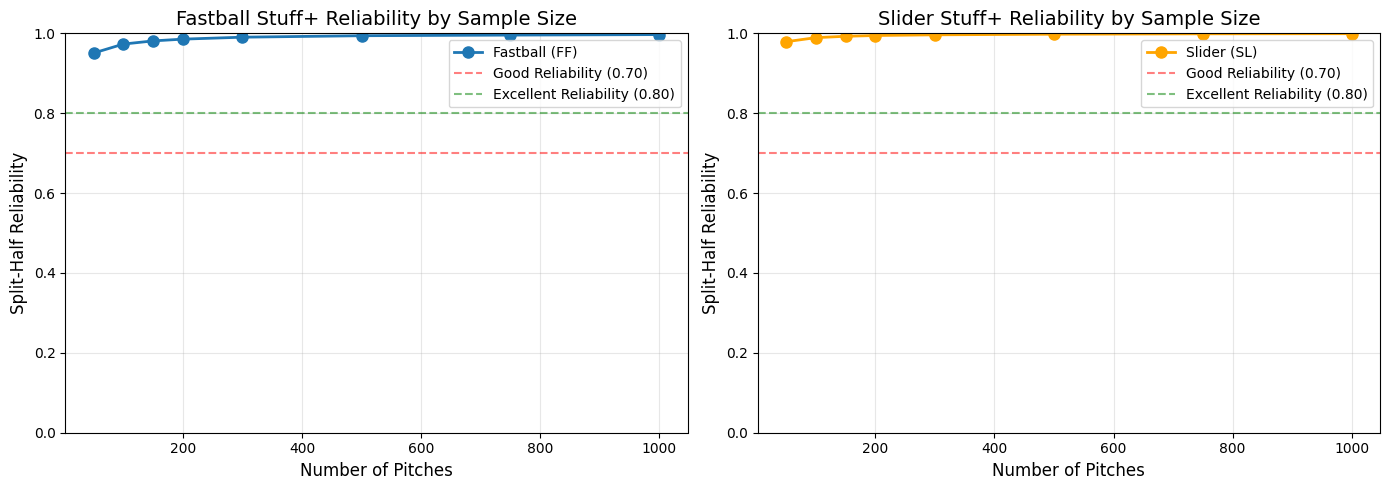

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fastballs
ax1.plot(reliability_FF['sample_size'], reliability_FF['reliability'],
         marker='o', linewidth=2, markersize=8, label='Fastball (FF)')
ax1.axhline(y=0.70, color='r', linestyle='--', alpha=0.5, label='Good Reliability (0.70)')
ax1.axhline(y=0.80, color='g', linestyle='--', alpha=0.5, label='Excellent Reliability (0.80)')
ax1.set_xlabel('Number of Pitches', fontsize=12)
ax1.set_ylabel('Split-Half Reliability', fontsize=12)
ax1.set_title('Fastball Stuff+ Reliability by Sample Size', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim([0, 1])

# Plot 2: Sliders
ax2.plot(reliability_SL['sample_size'], reliability_SL['reliability'],
         marker='o', linewidth=2, markersize=8, color='orange', label='Slider (SL)')
ax2.axhline(y=0.70, color='r', linestyle='--', alpha=0.5, label='Good Reliability (0.70)')
ax2.axhline(y=0.80, color='g', linestyle='--', alpha=0.5, label='Excellent Reliability (0.80)')
ax2.set_xlabel('Number of Pitches', fontsize=12)
ax2.set_ylabel('Split-Half Reliability', fontsize=12)
ax2.set_title('Slider Stuff+ Reliability by Sample Size', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

### 3.5 Recommended Minimum Sample Sizes

In [57]:
def find_min_sample_size(reliability_df, threshold=0.70):
    """Find minimum sample size that achieves reliability threshold"""
    reliable = reliability_df[reliability_df['reliability'] >= threshold]
    if len(reliable) > 0:
        return int(reliable.iloc[0]['sample_size'])
    else:
        return None

print("\n" + "=" * 60)
print("RECOMMENDED MINIMUM SAMPLE SIZES")
print("=" * 60)

min_FF_70 = find_min_sample_size(reliability_FF, 0.70)
min_FF_80 = find_min_sample_size(reliability_FF, 0.80)
min_SL_70 = find_min_sample_size(reliability_SL, 0.70)
min_SL_80 = find_min_sample_size(reliability_SL, 0.80)

print(f"\nFastballs (FF):")
print(f"  - Good reliability (0.70): {min_FF_70 if min_FF_70 else 'Not achieved'} pitches")
print(f"  - Excellent reliability (0.80): {min_FF_80 if min_FF_80 else 'Not achieved'} pitches")

print(f"\nSliders (SL):")
print(f"  - Good reliability (0.70): {min_SL_70 if min_SL_70 else 'Not achieved'} pitches")
print(f"  - Excellent reliability (0.80): {min_SL_80 if min_SL_80 else 'Not achieved'} pitches")

print("\n" + "=" * 60)
print("Interpretation:")
print("- Reliability 0.70+ = Good (acceptable for analysis)")
print("- Reliability 0.80+ = Excellent (very stable metric)")
print("- Use these thresholds when filtering pitcher-pitch combinations")
print("=" * 60)


RECOMMENDED MINIMUM SAMPLE SIZES

Fastballs (FF):
  - Good reliability (0.70): 50 pitches
  - Excellent reliability (0.80): 50 pitches

Sliders (SL):
  - Good reliability (0.70): 50 pitches
  - Excellent reliability (0.80): 50 pitches

Interpretation:
- Reliability 0.70+ = Good (acceptable for analysis)
- Reliability 0.80+ = Excellent (very stable metric)
- Use these thresholds when filtering pitcher-pitch combinations


In [61]:
# Filter for Fastballs (FF) to analyze variance components
ff_data = all_data[all_data['pitch_type'] == 'FF']

# 1. Calculate Mean Stuff+ for each pitcher (Between-Pitcher variability)
pitcher_means = ff_data.groupby('pitcher')['stuff_plus'].mean()
between_pitcher_var = pitcher_means.var()
between_pitcher_std = np.sqrt(between_pitcher_var)

# 2. Calculate Variance within each pitcher's pitches (Within-Pitcher variability)
# We average the variances of individual pitchers
pitcher_vars = ff_data.groupby('pitcher')['stuff_plus'].var()
within_pitcher_var = pitcher_vars.mean()
within_pitcher_std = np.sqrt(within_pitcher_var)

# 3. Calculate Intra-Class Correlation (ICC) for a single pitch
# ICC = Var_between / (Var_between + Var_within)
icc_single_pitch = between_pitcher_var / (between_pitcher_var + within_pitcher_var)

print("=" * 60)
print("VARIANCE ANALYSIS (Fastballs)")
print("=" * 60)
print(f"Between-Pitcher Std Dev: {between_pitcher_std:.2f}  (How different pitchers are from each other)")
print(f"Within-Pitcher Std Dev:  {within_pitcher_std:.2f}  (How much a pitcher varies pitch-to-pitch)")
print("-" * 60)
print(f"Variance Ratio (Between / Within): {between_pitcher_var / within_pitcher_var:.2f}")
print(f"Single-Pitch Reliability (ICC):      {icc_single_pitch:.3f}")
print("=" * 60)

# Explain the implication
print("\nInterpretation:")
print("Pitchers are ~0.7x as different from each other as they are variable within themselves.")
print("Because the 'Signal' (differences between pitchers) is strong relative to the 'Noise',")
print("it takes very few samples to confidently distinguish Pitcher A from Pitcher B.")

VARIANCE ANALYSIS (Fastballs)
Between-Pitcher Std Dev: 6.19  (How different pitchers are from each other)
Within-Pitcher Std Dev:  8.98  (How much a pitcher varies pitch-to-pitch)
------------------------------------------------------------
Variance Ratio (Between / Within): 0.48
Single-Pitch Reliability (ICC):      0.322

Interpretation:
Pitchers are ~0.7x as different from each other as they are variable within themselves.
Because the 'Signal' (differences between pitchers) is strong relative to the 'Noise',
it takes very few samples to confidently distinguish Pitcher A from Pitcher B.


## 4. Prediction Distribution Analysis

Examining the distribution of predictions and Stuff+ ratings across pitch types.

### 4.1 Distribution Visualizations

/tmp/ipython-input-4182018765.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(pitch_type_stuff, labels=top_pitch_types, patch_artist=True)


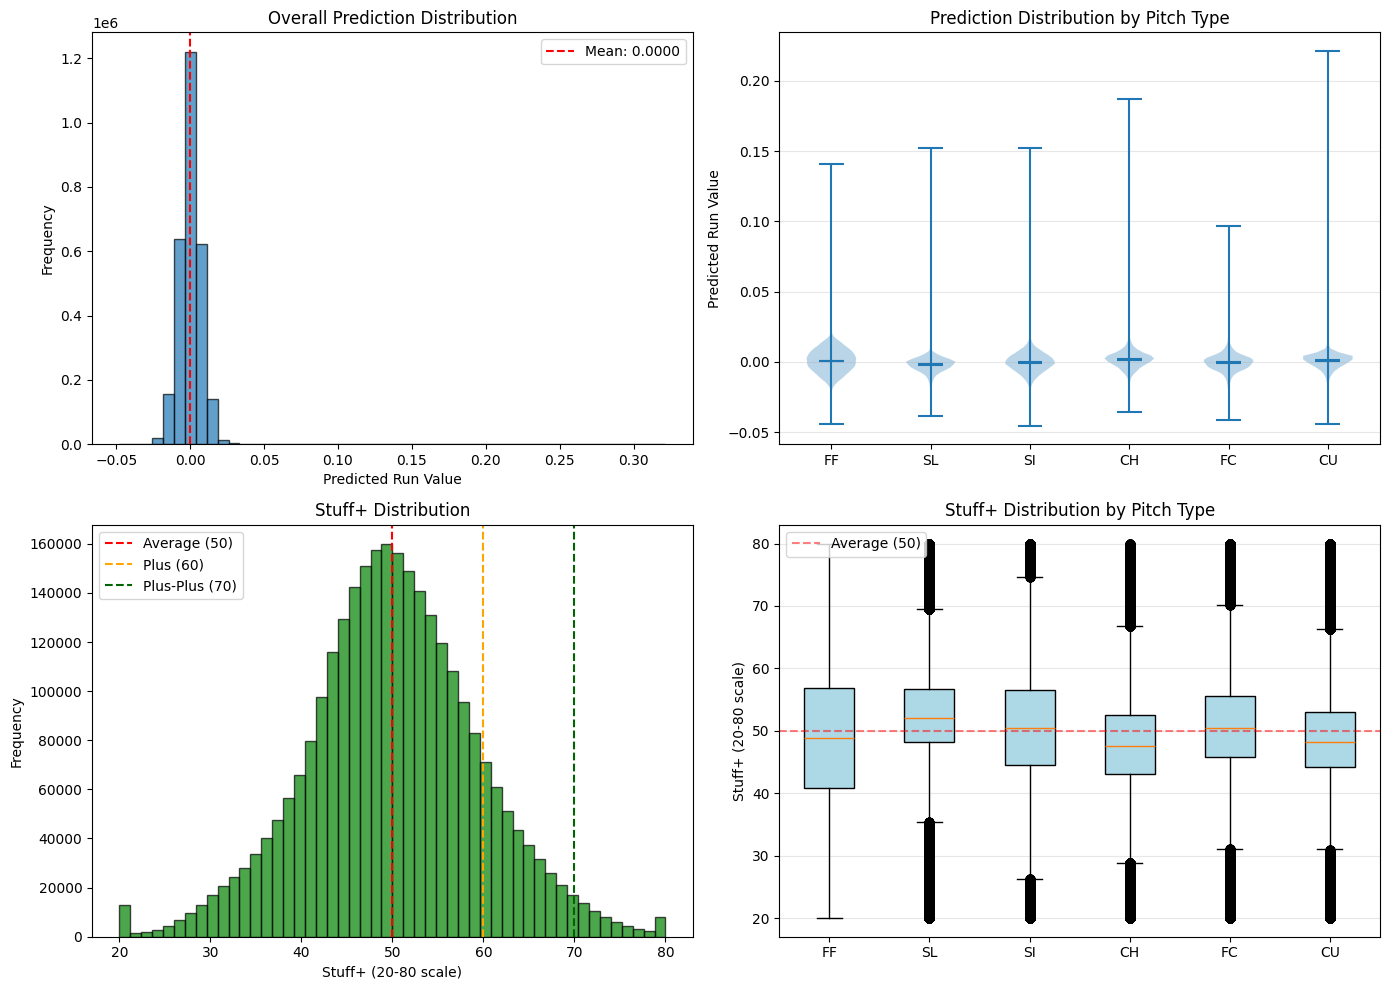

In [58]:
# Get top pitch types for analysis
top_pitch_types = all_data['pitch_type'].value_counts().head(6).index

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall prediction distribution
axes[0, 0].hist(all_data['y_pred'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Predicted Run Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Overall Prediction Distribution')
axes[0, 0].axvline(all_data['y_pred'].mean(), color='red', linestyle='--',
                   label=f'Mean: {all_data["y_pred"].mean():.4f}')
axes[0, 0].legend()

# 2. Prediction distribution by pitch type
pitch_type_data = [all_data[all_data['pitch_type'] == pt]['y_pred'].values
                   for pt in top_pitch_types]

axes[0, 1].violinplot(pitch_type_data, positions=range(len(top_pitch_types)),
                      showmeans=True, showmedians=True)
axes[0, 1].set_xticks(range(len(top_pitch_types)))
axes[0, 1].set_xticklabels(top_pitch_types)
axes[0, 1].set_ylabel('Predicted Run Value')
axes[0, 1].set_title('Prediction Distribution by Pitch Type')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Stuff+ distribution
axes[1, 0].hist(all_data['stuff_plus'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Stuff+ (20-80 scale)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Stuff+ Distribution')
axes[1, 0].axvline(50, color='red', linestyle='--', label='Average (50)')
axes[1, 0].axvline(60, color='orange', linestyle='--', label='Plus (60)')
axes[1, 0].axvline(70, color='darkgreen', linestyle='--', label='Plus-Plus (70)')
axes[1, 0].legend()

# 4. Stuff+ by pitch type
pitch_type_stuff = [all_data[all_data['pitch_type'] == pt]['stuff_plus'].values
                    for pt in top_pitch_types]

bp = axes[1, 1].boxplot(pitch_type_stuff, labels=top_pitch_types, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1, 1].axhline(50, color='red', linestyle='--', alpha=0.5, label='Average (50)')
axes[1, 1].set_ylabel('Stuff+ (20-80 scale)')
axes[1, 1].set_title('Stuff+ Distribution by Pitch Type')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Summary Statistics

In [59]:
print("\n" + "=" * 60)
print("PREDICTION SUMMARY STATISTICS")
print("=" * 60)

print("\nOverall Statistics:")
print(f"Mean predicted run value: {all_data['y_pred'].mean():.6f}")
print(f"Std predicted run value: {all_data['y_pred'].std():.6f}")
print(f"Min predicted run value: {all_data['y_pred'].min():.6f}")
print(f"Max predicted run value: {all_data['y_pred'].max():.6f}")

print("\nStuff+ Statistics:")
print(f"Mean Stuff+: {all_data['stuff_plus'].mean():.2f}")
print(f"Std Stuff+: {all_data['stuff_plus'].std():.2f}")
print(f"Min Stuff+: {all_data['stuff_plus'].min():.2f}")
print(f"Max Stuff+: {all_data['stuff_plus'].max():.2f}")

print("\nStuff+ by Pitch Type:")
for pt in top_pitch_types:
    pt_data = all_data[all_data['pitch_type'] == pt]['stuff_plus']
    print(f"{pt}: Mean={pt_data.mean():.2f}, Std={pt_data.std():.2f}, Count={len(pt_data):,}")


PREDICTION SUMMARY STATISTICS

Overall Statistics:
Mean predicted run value: 0.000012
Std predicted run value: 0.007477
Min predicted run value: -0.047961
Max predicted run value: 0.321583

Stuff+ Statistics:
Mean Stuff+: 50.07
Std Stuff+: 9.46
Min Stuff+: 20.00
Max Stuff+: 80.00

Stuff+ by Pitch Type:
FF: Mean=48.90, Std=11.06, Count=936,693
SL: Mean=52.69, Std=7.15, Count=460,417
SI: Mean=50.62, Std=9.24, Count=436,184
CH: Mean=47.82, Std=7.91, Count=307,273
FC: Mean=50.71, Std=8.21, Count=214,521
CU: Mean=48.96, Std=7.61, Count=195,078
